<a href="https://colab.research.google.com/github/DalpesCS50/trab_estagio4_health-insurance-claims-prediction/blob/main/notebooks/Pre_processamento_health_insurance_revisado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pré-processamento de dados — HEALTH INSURANCE

Adaptação do notebook do professor ao problema de previsão de `claim`.

1. Importar bibliotecas
2. Carregar e inspecionar os dados
3. Avaliar a remoção de variáveis
4. Tratar valores ausentes
5. Explorar distribuições e transformações
6. Demonstrar escalonamento e preparar as variáveis preditoras
7. Aplicar PCA

Este notebook segue o percurso didático do original e termina nas observações sobre treino/teste. As estatísticas e transformações aqui são calculadas sobre a base completa para exploração. Não devem ser reutilizadas como pré-processamento de uma avaliação preditiva com teste reservado. Mediana, One-Hot Encoding e retenção de 95% da variância são escolhas desta adaptação, não etapas executadas dessa forma no original.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

## Dados

Base `healthinsurance.csv` do projeto HEALTH INSURANCE. A variável resposta é `claim`; as demais colunas são candidatas a preditoras. Todas as análises deste notebook utilizam exclusivamente a base HEALTH INSURANCE.

In [2]:
url = "https://raw.githubusercontent.com/DalpesCS50/trab_estagio4_health-insurance-claims-prediction/refs/heads/main/data/healthinsurance.csv"
df_raw = pd.read_csv(url)
df = df_raw.copy(deep=True)
display(df.head())
print("Dimensão:", df.shape)
df.info()

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7


Dimensão: (15000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  14604 non-null  float64
 1   sex                  15000 non-null  object 
 2   weight               15000 non-null  int64  
 3   bmi                  14044 non-null  float64
 4   hereditary_diseases  15000 non-null  object 
 5   no_of_dependents     15000 non-null  int64  
 6   smoker               15000 non-null  int64  
 7   city                 15000 non-null  object 
 8   bloodpressure        15000 non-null  int64  
 9   diabetes             15000 non-null  int64  
 10  regular_ex           15000 non-null  int64  
 11  job_title            15000 non-null  object 
 12  claim                15000 non-null  float64
dtypes: float64(3), int64(6), object(4)
memory usage: 1.5+ MB


### Verificação dos valores de bloodpressure

Além das ausências, examinamos valores iguais a zero. A execução anterior identificou 756 registros (5,04% da base). O código abaixo recalcula o diagnóstico na base original. Por enquanto, os zeros são preservados: seu significado precisa ser confirmado na documentação antes de definir um tratamento. Esta célula não modifica os dados.

In [3]:
zeros_bp = df_raw['bloodpressure'].eq(0)
print("Registros com bloodpressure igual a zero:", zeros_bp.sum())
print(f"Percentual da base: {zeros_bp.mean():.2%}")
display(df_raw.loc[zeros_bp].head(10))
print("Estatísticas de bloodpressure sem os zeros:")
display(df_raw.loc[~zeros_bp, 'bloodpressure'].describe())

Registros com bloodpressure igual a zero: 756
Percentual da base: 5.04%


,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
10,51.0,female,50,33.0,EyeDisease,0,1,Syracuse,0,1,0,Police,44400.4
12,19.0,male,45,24.6,NoDisease,1,0,York,0,0,1,Student,1837.2
15,56.0,male,67,40.3,NoDisease,0,0,WashingtonDC,0,1,0,Engineer,10602.4
24,21.0,male,45,25.7,NoDisease,4,1,Charlotte,0,1,0,Actor,17942.1
45,56.0,male,67,40.3,NoDisease,0,0,IowaCity,0,1,0,Engineer,10602.4
120,51.0,female,50,33.0,EyeDisease,0,1,Tucson,0,1,0,Police,44400.4
123,51.0,female,50,33.0,EyeDisease,0,1,Kingman,0,1,0,Police,44400.4
128,40.0,male,62,25.0,NoDisease,2,0,Kingman,0,1,0,Clerks,6593.5
130,63.0,female,69,25.1,NoDisease,0,0,Mexicali,0,1,1,Manager,14254.6
204,46.0,male,52,33.3,NoDisease,1,0,Atlanta,0,0,0,Photographer,8334.5


Estatísticas de bloodpressure sem os zeros:


,bloodpressure
count,14244.000000
mean,72.293738
std,11.561371
min,40.000000
25%,64.000000
50%,72.000000
75%,80.000000
max,122.000000


### Resultado da verificação de bloodpressure

Foram identificados 756 registros com `bloodpressure` igual a zero, correspondentes a 5,04% da base HEALTH INSURANCE. Considerando somente os valores diferentes de zero, a variável apresenta 14.244 observações, mínimo de 40, máximo de 122, média de 72,29 e mediana de 72.

Os zeros foram preservados nesta etapa. Esse diagnóstico identifica uma questão de qualidade dos dados, mas não permite determinar, isoladamente, se os valores representam ausência, erro de registro ou uma codificação específica.

In [4]:
display(df[['age', 'bmi']].mean())

,0
age,39.547521
bmi,30.266413


In [5]:
display(df.loc[[0, 1, 10], ['age', 'bmi', 'claim']])
display(df.iloc[0:3, 10:])

,age,bmi,claim
0,60.0,24.3,13112.6
1,49.0,22.6,9567.0
10,51.0,33.0,44400.4


,regular_ex,job_title,claim
0,0,Actor,13112.6
1,1,Engineer,9567.0
2,1,Academician,32734.2


## Avaliação de variáveis para remoção

A avaliação de remoção considera exclusivamente as variáveis disponíveis na base HEALTH INSURANCE. Mantemos as variáveis disponíveis, inclusive `smoker` e `job_title`. A cardinalidade, isoladamente, não determina a exclusão de uma variável.

In [6]:
categorical_cols = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} categorias")
    display(df[col].value_counts())
var_remover = []
df = df.drop(columns=var_remover)

sex: 2 categorias


,count
sex,
female,7652
male,7348


hereditary_diseases: 10 categorias


,count
hereditary_diseases,
NoDisease,13998
Diabetes,148
Alzheimer,144
Obesity,136
EyeDisease,123
Cancer,109
Arthritis,96
HeartDisease,93
Epilepsy,84


city: 91 categorias


,count
city,
Nashville,302
NewOrleans,302
Charleston,298
Brimingham,298
Memphis,297
...,...
Warwick,69
Syracuse,69
Trenton,69


job_title: 35 categorias


,count
job_title,
Student,1320
HomeMakers,972
Singer,744
Actor,720
FilmMaker,714
Dancer,693
HouseKeeper,667
Manager,602
Police,412


## Valores ausentes

Utilizamos as ausências reais da base, sem acrescentar observações artificiais. O original demonstra média, mediana e moda e termina removendo linhas incompletas. Neste trabalho, escolhemos preencher `age` e `bmi` pela mediana para preservar as observações.

In [7]:
display(df.isna().sum())
display(df.isna().sum(axis=1).value_counts().sort_index())
numeric_cols = df.select_dtypes(include='number').columns
display(pd.DataFrame({'média': df[numeric_cols].mean(), 'mediana': df[numeric_cols].median()}))
display(df.mode().iloc[0])

,0
age,396
sex,0
weight,0
bmi,956
hereditary_diseases,0
no_of_dependents,0
smoker,0
city,0
bloodpressure,0
diabetes,0


,count
0,13648
1,1352


,média,mediana
age,39.547521,40.00
weight,64.909600,63.00
bmi,30.266413,29.40
no_of_dependents,1.129733,1.00
smoker,0.198133,0.00
bloodpressure,68.650133,71.00
diabetes,0.777000,1.00
regular_ex,0.224133,0.00
claim,13401.437620,9545.65


,0
age,18.0
sex,female
weight,56.0
bmi,33.3
hereditary_diseases,NoDisease
no_of_dependents,0.0
smoker,0.0
city,Nashville
bloodpressure,70.0
diabetes,1.0


In [21]:
# Preservar a base original e reconstruir a cópia de trabalho.
df = df_raw.copy()

# Tratar zeros de bloodpressure como ausências.
zeros_bp = df['bloodpressure'].eq(0)
df.loc[zeros_bp, 'bloodpressure'] = np.nan

colunas_imputacao = ['age', 'bmi', 'bloodpressure']
medianas = df[colunas_imputacao].median()

print("Zeros de bloodpressure convertidos em ausências:", zeros_bp.sum())

print("\nAusências antes da imputação:")
display(df[colunas_imputacao].isna().sum())

df[colunas_imputacao] = df[colunas_imputacao].fillna(medianas)

print("\nMedianas utilizadas:")
display(medianas)

print("\nAusências após o tratamento:")
display(df.isna().sum())

assert not df.isna().any().any(), "Ainda existem valores ausentes."
assert not df['bloodpressure'].eq(0).any(), "Ainda existem zeros em bloodpressure."
assert len(df) == len(df_raw), "A quantidade de observações foi alterada."
assert df['claim'].equals(df_raw['claim']), "A variável resposta foi alterada."

Zeros de bloodpressure convertidos em ausências: 756

Ausências antes da imputação:


,0
age,396
bmi,956
bloodpressure,756



Medianas utilizadas:


,0
age,40.0
bmi,29.4
bloodpressure,72.0



Ausências após o tratamento:


,0
age,0
sex,0
weight,0
bmi,0
hereditary_diseases,0
no_of_dependents,0
smoker,0
city,0
bloodpressure,0
diabetes,0


### Diagnóstico de zeros em pressão arterial

Esta célula identifica os registros com `bloodpressure` igual a zero na base original e apresenta as estatísticas dos demais valores. O diagnóstico não modifica `df_raw`. Na etapa de imputação, esses zeros serão tratados como ausências, conforme a decisão metodológica documentada.

## Distribuições e estatísticas descritivas

Examinamos as distribuições, as estatísticas descritivas e as frequências das variáveis da HEALTH INSURANCE.

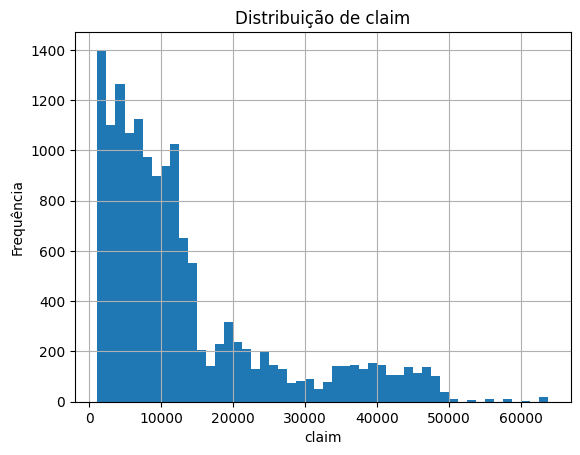

,count,mean,std,min,25%,50%,75%,max
age,15000.0,39.559467,13.829896,18.0,27.0,40.00,51.000,64.0
weight,15000.0,64.909600,13.701935,34.0,54.0,63.00,76.000,95.0
bmi,15000.0,30.211193,5.928386,16.0,25.9,29.40,34.100,53.1
no_of_dependents,15000.0,1.129733,1.228469,0.0,0.0,1.00,2.000,5.0
smoker,15000.0,0.198133,0.398606,0.0,0.0,0.00,0.000,1.0
bloodpressure,15000.0,72.278933,11.266422,40.0,64.0,72.00,80.000,122.0
diabetes,15000.0,0.777000,0.416272,0.0,1.0,1.00,1.000,1.0
regular_ex,15000.0,0.224133,0.417024,0.0,0.0,0.00,0.000,1.0
claim,15000.0,13401.437620,12148.239619,1121.9,4846.9,9545.65,16519.125,63770.4


In [22]:
df['claim'].hist(bins=50)
plt.title('Distribuição de claim')
plt.xlabel('claim')
plt.ylabel('Frequência')
plt.show()
display(df.describe().transpose())

Após a imputação pela mediana, todas as variáveis numéricas passaram a apresentar 15.000 observações preenchidas. A Tabela X reúne as estatísticas descritivas da base HEALTH INSURANCE após esse tratamento.

**[Inserir Tabela X — Estatísticas descritivas das variáveis numéricas após a imputação.]**

A variável resposta `claim` apresentou média de 13.401,44 e mediana de 9.545,65, indicando influência dos valores mais elevados sobre a média. Para visualizar essa distribuição, apresenta-se a Figura X.

**[Inserir Figura X — Distribuição dos valores de sinistros (`claim`).]**

Observa-se concentração de registros nos valores mais baixos e uma cauda à direita, evidenciando uma distribuição assimétrica. Essa característica motiva a comparação posterior com a transformação logarítmica, sem implicar, por si só, a exclusão dos sinistros elevados.

,count
sex,
female,7652
male,7348


,proportion
sex,
female,0.510133
male,0.489867


,smoker,diabetes,regular_ex
0,12028,3345,11638
1,2972,11655,3362


,smoker,diabetes,regular_ex
0,0.801867,0.223,0.775867
1,0.198133,0.777,0.224133


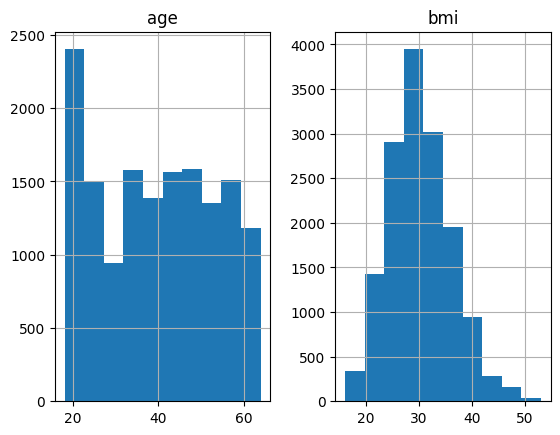

In [23]:
display(df['sex'].value_counts())
display(df['sex'].value_counts(normalize=True))
binary_cols = ['smoker', 'diabetes', 'regular_ex']
display(df[binary_cols].apply(pd.Series.value_counts))
display(df[binary_cols].apply(pd.Series.value_counts) / len(df))
df[['age', 'bmi']].hist()
plt.show()

,age,bmi,weight,claim
age,1.000000,0.180284,0.281542,0.298063
bmi,0.180284,1.000000,0.242398,0.196672
weight,0.281542,0.242398,1.000000,0.077716
claim,0.298063,0.196672,0.077716,1.000000


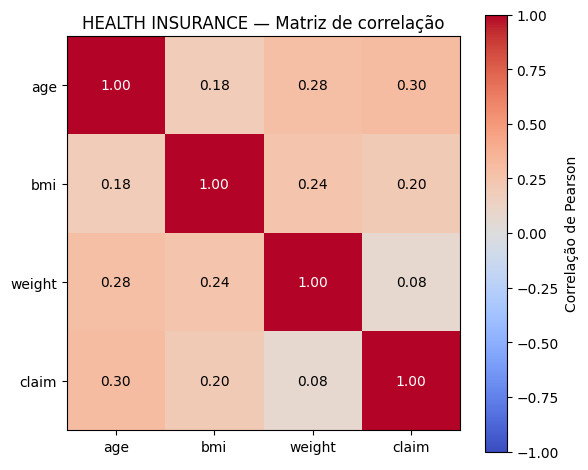

In [24]:
colunas_corr = ['age', 'bmi', 'weight', 'claim']
matriz_corr = df[colunas_corr].corr(method='pearson')

display(matriz_corr)

fig, ax = plt.subplots(figsize=(6, 5))

imagem = ax.imshow(
    matriz_corr,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

ax.set_xticks(np.arange(len(colunas_corr)))
ax.set_yticks(np.arange(len(colunas_corr)))
ax.set_xticklabels(colunas_corr)
ax.set_yticklabels(colunas_corr)

for i in range(len(colunas_corr)):
    for j in range(len(colunas_corr)):
        valor = matriz_corr.iloc[i, j]
        ax.text(
            j, i, f'{valor:.2f}',
            ha='center',
            va='center',
            color='white' if abs(valor) > 0.5 else 'black'
        )

fig.colorbar(imagem, ax=ax, label='Correlação de Pearson')
ax.set_title('HEALTH INSURANCE — Matriz de correlação')
fig.tight_layout()
plt.show()

### Demonstração de transformação logarítmica

Demonstramos a transformação logarítmica da variável resposta `claim`. Usamos `log1p` para admitir valores zero e `expm1` para retornar à escala original. O resultado serve apenas à análise da distribuição; `claim` permanece em sua escala original e não entra no PCA.

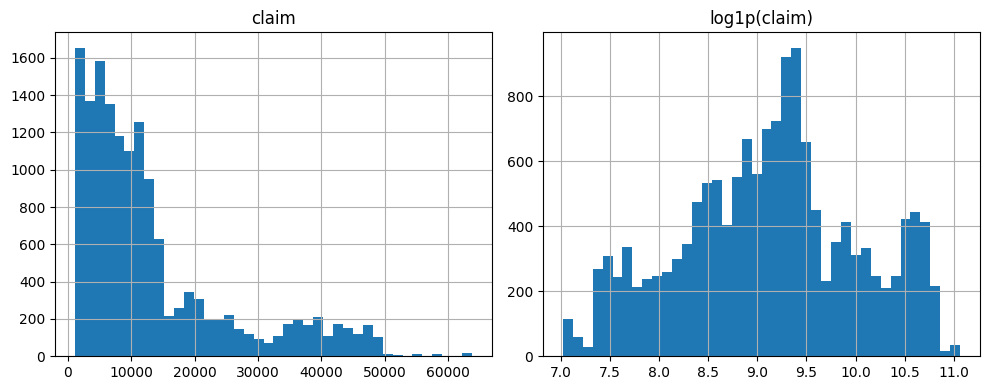

Retorno à escala original: True


In [25]:
assert (df['claim'] >= 0).all(), "A demonstração pressupõe claim não negativo."
claim_log = np.log1p(df['claim'])
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['claim'].hist(bins=40, ax=axes[0])
axes[0].set_title('claim')
claim_log.hist(bins=40, ax=axes[1])
axes[1].set_title('log1p(claim)')
plt.tight_layout()
plt.show()
print("Retorno à escala original:", np.allclose(np.expm1(claim_log), df['claim']))

## Escalonamento

Assim como no original, demonstramos StandardScaler e MinMaxScaler em idade e IMC. Padronizar centra e escala os dados; não garante uma distribuição normal. Os resultados da demonstração não substituem as colunas originais.

Médias: [39.55946667 30.21119333]
Escalas: [13.82943469  5.9281882 ]


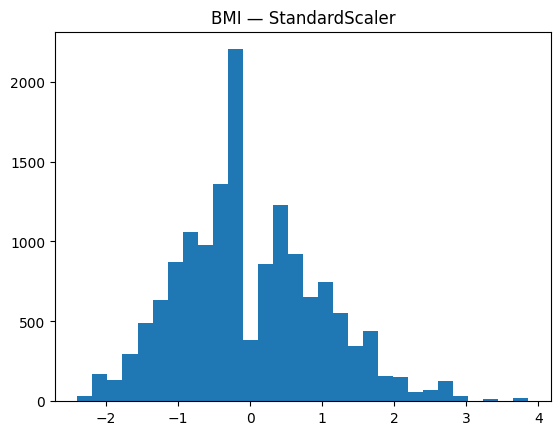

In [26]:
scaler = StandardScaler().fit(df[['age', 'bmi']])
age_bmi_scaled = scaler.transform(df[['age', 'bmi']])
print("Médias:", scaler.mean_)
print("Escalas:", scaler.scale_)
plt.hist(age_bmi_scaled[:, 1], bins=30)
plt.title('BMI — StandardScaler')
plt.show()

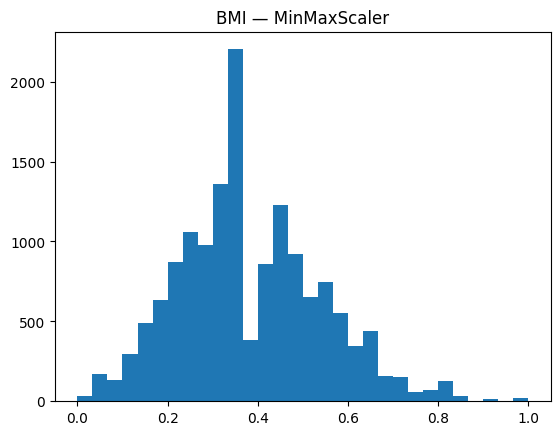

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim,age_norm,bmi_norm
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72.0,0,0,Actor,13112.6,0.913043,0.223720
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78.0,1,1,Engineer,9567.0,0.673913,0.177898
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88.0,1,1,Academician,32734.2,0.304348,0.048518
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72.0,1,0,Chef,48517.6,0.934783,0.549865
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82.0,1,0,HomeMakers,1731.7,0.021739,0.123989


In [27]:
minmax_scaler = MinMaxScaler().fit(df[['age', 'bmi']])
age_bmi_minmax = minmax_scaler.transform(df[['age', 'bmi']])
plt.hist(age_bmi_minmax[:, 1], bins=30)
plt.title('BMI — MinMaxScaler')
plt.show()
df[['age_norm', 'bmi_norm']] = age_bmi_minmax
display(df.head())
df = df.drop(columns=['age_norm', 'bmi_norm'])

### Preparação de X para o PCA — adaptação ao trabalho

Separamos `claim` como resposta e mantemos `job_title`. Preservamos as escolhas do trabalho: MinMaxScaler em `age` e `bmi`, StandardScaler em `weight` e `bloodpressure`, demais variáveis numéricas na escala existente e One-Hot Encoding nas categóricas.

A codificação é necessária porque o PCA exige entradas numéricas; ela não aparece no notebook original. A combinação de escalas influencia a variância e os componentes, portanto os resultados correspondem especificamente a estas escolhas. Esta preparação é exploratória, ajustada na base completa.

In [29]:
y = df['claim'].copy()
X = df.drop(columns='claim').copy()
minmax_final = MinMaxScaler()
standard_final = StandardScaler()
X[['age', 'bmi']] = minmax_final.fit_transform(X[['age', 'bmi']])
X[['weight', 'bloodpressure']] = standard_final.fit_transform(X[['weight', 'bloodpressure']])
categorical_cols = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=float)
X = X.astype(float)
assert 'claim' not in X.columns
assert np.isfinite(X.to_numpy()).all()
assert np.array_equal(y.to_numpy(), df_raw['claim'].to_numpy())
print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)
display(X.describe().transpose())
display(X[['bloodpressure']].describe())

Dimensão de X: (15000, 142)
Dimensão de y: (15000,)


,count,mean,std,min,25%,50%,75%,max
age,15000.0,4.686841e-01,0.300650,0.000000,0.195652,0.478261,0.717391,1.000000
weight,15000.0,1.743198e-16,1.000033,-2.255932,-0.796235,-0.139372,0.809431,2.196143
bmi,15000.0,3.830510e-01,0.159795,0.000000,0.266846,0.361186,0.487871,1.000000
no_of_dependents,15000.0,1.129733e+00,1.228469,0.000000,0.000000,1.000000,2.000000,5.000000
smoker,15000.0,1.981333e-01,0.398606,0.000000,0.000000,0.000000,0.000000,1.000000
...,...,...,...,...,...,...,...,...
job_title_Police,15000.0,2.746667e-02,0.163444,0.000000,0.000000,0.000000,0.000000,1.000000
job_title_Politician,15000.0,2.466667e-02,0.155112,0.000000,0.000000,0.000000,0.000000,1.000000
job_title_Singer,15000.0,4.960000e-02,0.217124,0.000000,0.000000,0.000000,0.000000,1.000000
job_title_Student,15000.0,8.800000e-02,0.283304,0.000000,0.000000,0.000000,0.000000,1.000000


,bloodpressure
count,1.500000e+04
mean,5.295912e-16
std,1.000033e+00
min,-2.865152e+00
25%,-7.348570e-01
50%,-2.475876e-02
75%,6.853395e-01
max,4.413355e+00


## PCA

Examinamos a variância explicada por todos os componentes. O número de componentes é calculado a partir das preditoras transformadas da HEALTH INSURANCE; a resposta claim não participa do ajuste.

array([2.44756969e-01, 1.55979385e-01, 1.50803373e-01, 3.85461335e-02,
       2.98236033e-02, 2.71508001e-02, 2.51349453e-02, 1.63774344e-02,
       1.00094740e-02, 8.93081943e-03, 7.71245174e-03, 7.62038130e-03,
       7.36391335e-03, 7.09286109e-03, 6.95571900e-03, 6.29732331e-03,
       5.56527523e-03, 4.28794520e-03, 4.15415738e-03, 4.05887592e-03,
       3.96298125e-03, 3.90828102e-03, 3.88446683e-03, 3.83361833e-03,
       3.80487236e-03, 3.79003934e-03, 3.67992742e-03, 3.52727894e-03,
       3.42740476e-03, 3.33568119e-03, 3.18797151e-03, 3.17230452e-03,
       3.15337700e-03, 3.12822395e-03, 3.09936826e-03, 3.08048468e-03,
       3.05698839e-03, 3.03080399e-03, 3.01591674e-03, 2.97543144e-03,
       2.96417053e-03, 2.95405854e-03, 2.91957113e-03, 2.90529957e-03,
       2.88315582e-03, 2.86252711e-03, 2.84275511e-03, 2.81361692e-03,
       2.80228555e-03, 2.74092036e-03, 2.69762924e-03, 2.67114636e-03,
       2.62841689e-03, 2.59638687e-03, 2.57539033e-03, 2.47189256e-03,
      

array([0.24475697, 0.40073635, 0.55153973, 0.59008586, 0.61990946,
       0.64706026, 0.67219521, 0.68857264, 0.69858212, 0.70751294,
       0.71522539, 0.72284577, 0.73020968, 0.73730254, 0.74425826,
       0.75055559, 0.75612086, 0.76040881, 0.76456296, 0.76862184,
       0.77258482, 0.7764931 , 0.78037757, 0.78421119, 0.78801606,
       0.7918061 , 0.79548603, 0.79901331, 0.80244071, 0.80577639,
       0.80896436, 0.81213667, 0.81529004, 0.81841827, 0.82151764,
       0.82459812, 0.82765511, 0.83068591, 0.83370183, 0.83667726,
       0.83964143, 0.84259549, 0.84551506, 0.84842036, 0.85130352,
       0.85416604, 0.8570088 , 0.85982242, 0.8626247 , 0.86536562,
       0.86806325, 0.8707344 , 0.87336281, 0.8759592 , 0.87853459,
       0.88100648, 0.88344467, 0.88586983, 0.88827896, 0.89061788,
       0.89281859, 0.89490078, 0.89697459, 0.89904136, 0.90110199,
       0.90315548, 0.90520391, 0.90724771, 0.90928994, 0.91132599,
       0.91334277, 0.9152649 , 0.91707384, 0.9188793 , 0.92067

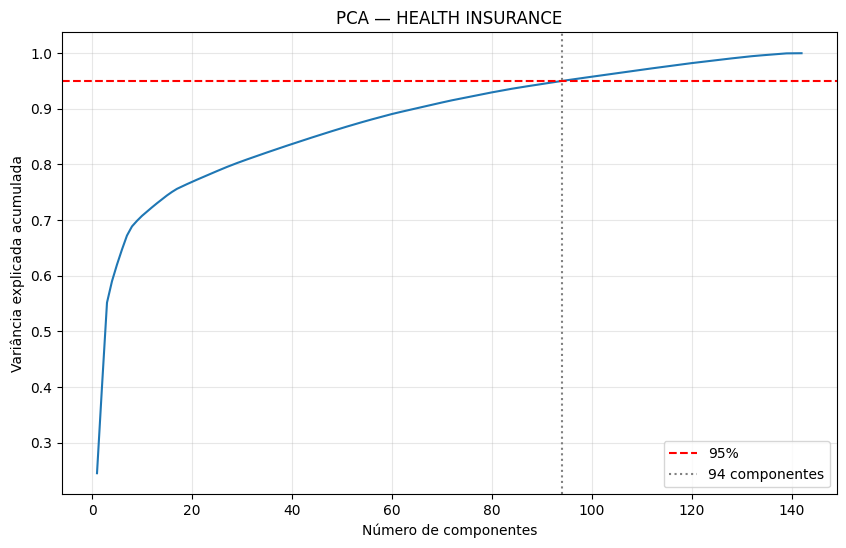

In [30]:
pca = PCA(svd_solver='full')
pca.fit(X)
variancia_acumulada = np.cumsum(pca.explained_variance_ratio_)
display(pca.explained_variance_ratio_)
display(variancia_acumulada)
n_components = int(np.searchsorted(variancia_acumulada, 0.95) + 1)
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(variancia_acumulada) + 1), variancia_acumulada)
plt.axhline(0.95, color='red', linestyle='--', label='95%')
plt.axvline(n_components, color='gray', linestyle=':',
            label=f'{n_components} componentes')
plt.xlabel('Número de componentes')
plt.ylabel('Variância explicada acumulada')
plt.title('PCA — HEALTH INSURANCE')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Escolha e aplicação dos componentes

Como critério desta adaptação, retemos pelo menos 95% da variância. O número de componentes e a proporção alcançada são informados pela execução, sem fixar antecipadamente o valor 94. O ajuste final utiliza exclusivamente `X`, nunca `df` com a resposta.

In [31]:
n_components = int(np.searchsorted(variancia_acumulada, 0.95) + 1)
pca_final = PCA(n_components=n_components, svd_solver='full')
pca_final.fit(X)
df_pca = pca_final.transform(X)
df_pca_final = pd.DataFrame(df_pca, index=X.index,
                            columns=[f'PC_{i+1}' for i in range(n_components)])
print(f"Componentes selecionados: {n_components}")
print(f"Variância explicada: {pca_final.explained_variance_ratio_.sum():.2%}")
display(df_pca_final.head())
print("Dimensão após PCA:", df_pca.shape)
assert df_pca.shape == (len(X), n_components)

Componentes selecionados: 94
Variância explicada: 95.01%


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_85,PC_86,PC_87,PC_88,PC_89,PC_90,PC_91,PC_92,PC_93,PC_94
0,-0.134509,-0.018882,0.075649,0.433760,-0.595713,-0.594245,-0.102931,0.513368,-0.192417,0.028284,...,0.091047,-0.058890,-0.000440,-0.005787,0.001601,-0.023151,0.017048,-0.024142,-0.015716,0.040917
1,0.129385,0.649014,0.606724,-0.590470,-0.175897,0.761660,-0.212852,0.008139,-0.079955,-0.021464,...,0.105920,0.072538,-0.010391,0.015589,0.013488,-0.001700,0.002385,-0.017528,-0.018479,0.051466
2,0.905224,1.301904,-0.608085,-0.204510,0.826510,0.535449,-0.982400,-0.100965,-0.004147,-0.113415,...,0.082232,0.054606,0.013470,-0.003963,0.017025,-0.028022,0.046553,-0.018209,-0.059115,0.079399
3,-0.368064,-0.123703,-0.766867,-0.279498,0.810904,-0.075449,-0.172225,0.474652,-0.161851,0.145795,...,0.085361,-0.108725,0.004321,-0.005514,-0.004967,-0.013156,-0.001729,-0.014783,0.019433,0.024119
4,-1.360067,0.834891,-0.933151,-0.423484,0.090044,-0.060714,0.298787,-0.151869,0.983685,0.165495,...,-0.135241,-0.132274,-0.015788,-0.050642,-0.142309,0.759799,-0.258712,-0.424708,-0.137833,0.225435


Dimensão após PCA: (15000, 94)


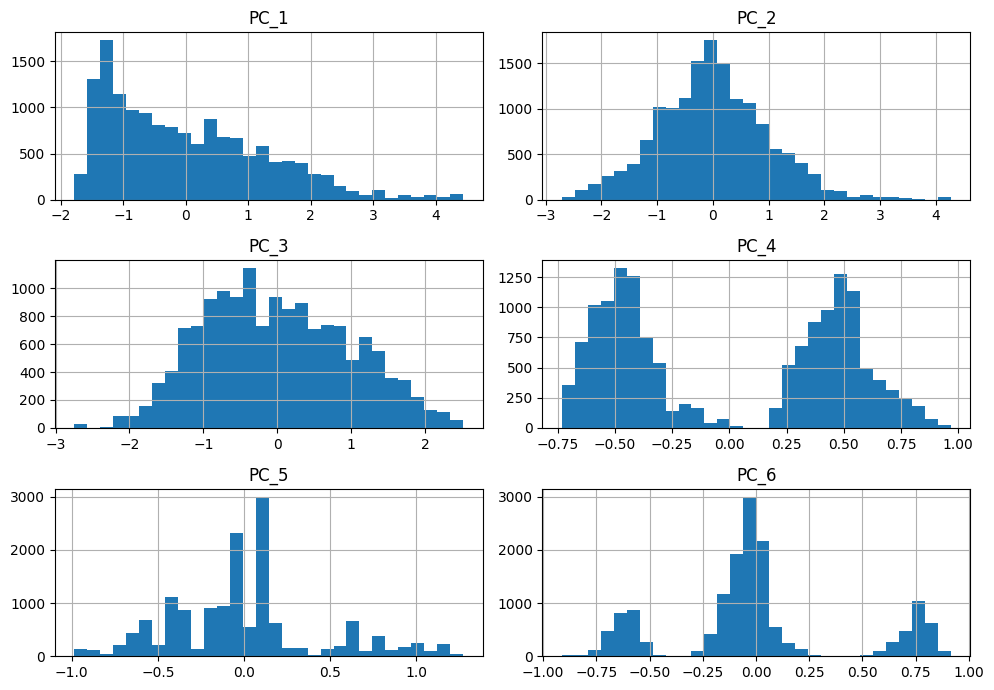

In [32]:
# Histogramas dos primeiros componentes para manter a visualização legível
df_pca_final.iloc[:, :min(6, n_components)].hist(figsize=(10, 7), bins=30)
plt.tight_layout()
plt.show()

## Observações finais — orientação do professor

Estimar as transformações e o PCA nos dados de treinamento e, depois, aplicar as transformações ao treino e ao teste. Nunca utilizar o teste para ajustar modelos ou estimar transformações.

- Ajustar apenas no treino: `pca.fit(X_treinamento)`.
- Aplicar em ambos: `pca.transform(X_treinamento)` e `pca.transform(X_teste)`.
- A mesma regra vale para medianas, escalonamento e codificação de categorias.

O notebook termina aqui, como o original. Para uma futura avaliação preditiva, será necessário partir de `df_raw`, separar treino/teste antes da imputação e aprender todas as transformações somente no treino. Os componentes exploratórios deste notebook não são conjuntos de treino/teste prontos para avaliar um modelo.

Os zeros em bloodpressure foram apenas diagnosticados e preservados. Se houver mudança no tratamento após a investigação de sua origem, as transformações e o PCA deverão ser recalculados.